<a href="https://colab.research.google.com/github/shavel28/StockSight-AI-PJK-GM073/blob/main/Notebooks/Data_Engineering_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROJECT: STOCKSIGHT AI (PJK-GM073)

ROLE: DATA ENGINEER (Shava Selvia Ramadhani Subekti)

TASK: Data Pipeline, Cleaning, Holiday Integration, ROP & Safety Stock

1. INSTALL & IMPORT LIBRARIES

In [1]:
!pip install kagglehub holidays -q
import pandas as pd
import numpy as np
import holidays
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

 2. DATA INGESTION (Ambil Data dari Kaggle)

In [2]:
print("--- Mengunduh Dataset ---")
path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")
file_path = os.path.join(path, "train.csv") # Menyesuaikan path dari kagglehub
df_raw = pd.read_csv(file_path)
print(f"Dataset berhasil dimuat. Ukuran: {df_raw.shape}")

--- Mengunduh Dataset ---


100%|██████████| 480k/480k [00:00<00:00, 1.11MB/s]

Extracting files...
Dataset berhasil dimuat. Ukuran: (9800, 18)


 3. EXPLORATORY DATA ANALYSIS (EDA) AWAL

In [3]:
print("\n--- Menjalankan EDA ---")
print(df_raw.info())
print("\nStatistik Penjualan:")
print(df_raw['Sales'].describe())


--- Menjalankan EDA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-nul

 4. DATA CLEANING & VALIDASI INPUT

In [4]:
print("\n--- Memulai Proses Cleaning ---")
# Hapus Duplikasi
before_dup = len(df_raw)
df_cleaned = df_raw.drop_duplicates()
print(f"Duplikasi dihapus: {before_dup - len(df_cleaned)}")

# Handling Missing Value (Validasi kolom Sales dan Date)
before_null = len(df_cleaned)
df_cleaned = df_cleaned.dropna(subset=['Sales', 'Order Date'])
print(f"Baris kosong dihapus: {before_null - len(df_cleaned)}")

# Validasi Format Tanggal (Sangat penting untuk Time Series) [cite: 55]
df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'], dayfirst=True)


--- Memulai Proses Cleaning ---
Duplikasi dihapus: 0
Baris kosong dihapus: 0


5. INTEGRASI DATASET EKSTERNAL (Holiday Indonesia)

In [5]:
print("\n--- Integrasi Data Libur Indonesia ---")
id_holidays = holidays.Indonesia(years=range(2015, 2025))
df_cleaned['is_holiday'] = df_cleaned['Order Date'].apply(lambda x: 1 if x in id_holidays else 0)


--- Integrasi Data Libur Indonesia ---


6. TRANSFORMASI KE TIME SERIES (Untuk ML Engineer)

In [6]:
# Mengelompokkan data per hari untuk kebutuhan Prophet/ARIMA
df_ts = df_cleaned.groupby('Order Date').agg({'Sales': 'sum', 'is_holiday': 'max'}).reset_index()
df_ts.columns = ['ds', 'y', 'is_holiday'] # ds dan y adalah standar kolom Prophet
df_ts = df_ts.sort_values('ds')

7. VISUALISASI EVALUASI DATA (CEK KUALITAS SECARA VISUAL)



--- Menampilkan Grafik Evaluasi Data ---


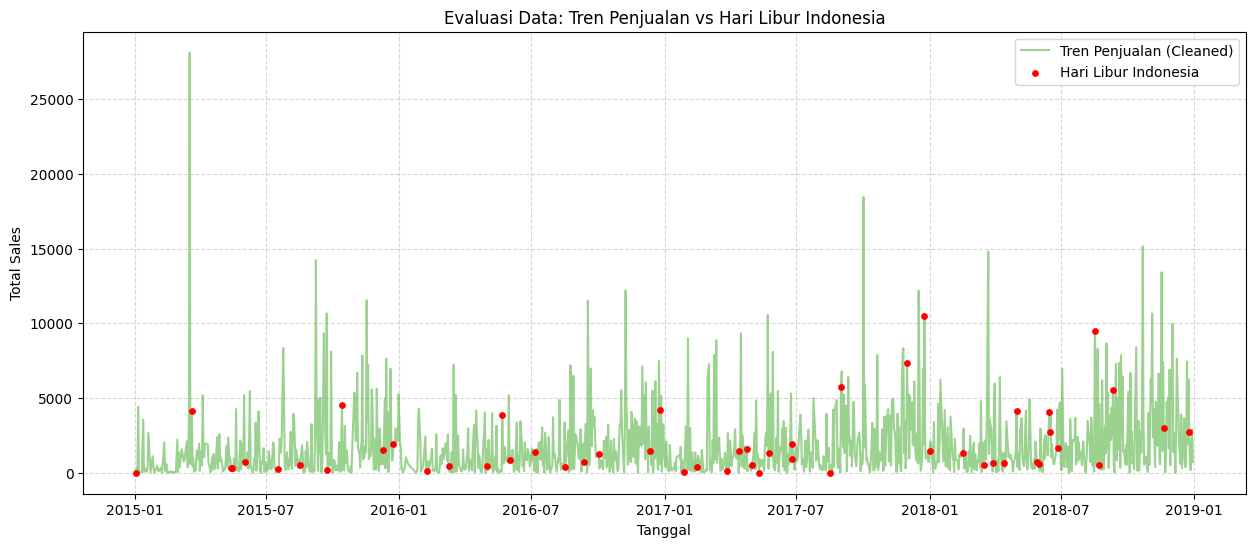

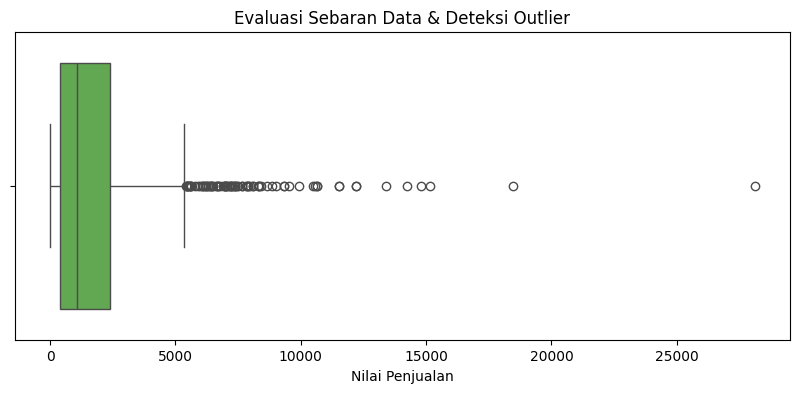

In [7]:

print("\n--- Menampilkan Grafik Evaluasi Data ---")
plt.figure(figsize=(15, 6))

# Plot Tren Penjualan Harian
plt.plot(df_ts['ds'], df_ts['y'], label='Tren Penjualan (Cleaned)', color='#59B544', alpha=0.6)

# Tandai Hari Libur dengan titik merah
holiday_points = df_ts[df_ts['is_holiday'] == 1]
plt.scatter(holiday_points['ds'], holiday_points['y'], color='red', s=15, label='Hari Libur Indonesia', zorder=5)

plt.title('Evaluasi Data: Tren Penjualan vs Hari Libur Indonesia')
plt.xlabel('Tanggal')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Boxplot untuk cek sebaran dan Outlier
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_ts['y'], color='#59B544')
plt.title('Evaluasi Sebaran Data & Deteksi Outlier')
plt.xlabel('Nilai Penjualan')
plt.show()

 8. PERHITUNGAN SAFETY STOCK & REORDER POINT (ROP)

In [8]:
print("\n--- Menghitung Metrik Inventori ---")
lead_time = 7 # Asumsi waktu pengiriman 7 hari
avg_daily_sales = df_ts['y'].mean()
max_daily_sales = df_ts['y'].max()

# Rumus: (Max Sales * Lead Time) - (Avg Sales * Lead Time)
safety_stock = (max_daily_sales * lead_time) - (avg_daily_sales * lead_time)

# Rumus: (Avg Sales * Lead Time) + Safety Stock
rop = (avg_daily_sales * lead_time) + safety_stock

# Simpan hasil metrik ke DataFrame ringkasan
inventory_summary = pd.DataFrame({
'Metric': ['Average Daily Sales', 'Lead Time (Days)', 'Safety Stock', 'Reorder Point (ROP)'],
'Value': [round(avg_daily_sales, 2), lead_time, round(safety_stock, 2), round(rop, 2)]
})


--- Menghitung Metrik Inventori ---


9. EVALUASI KUALITAS DATA (Quality Control)

In [9]:
print("\n--- LAPORAN EVALUASI DATA (QC) ---")
qc_report = {
    "Missing Values": df_ts.isnull().sum().sum(),
    "Duplicated Rows": df_ts.duplicated().sum(),
    "Data Points": len(df_ts),
    "Date Range": f"{df_ts['ds'].min()} s/d {df_ts['ds'].max()}",
    "Status": "BAGUS / SIAP PAKAI" if df_ts.isnull().sum().sum() == 0 else "PERLU CEK ULANG"
}
for key, value in qc_report.items():
    print(f"- {key}: {value}")


--- LAPORAN EVALUASI DATA (QC) ---
- Missing Values: 0
- Duplicated Rows: 0
- Data Points: 1230
- Date Range: 2015-01-03 00:00:00 s/d 2018-12-30 00:00:00
- Status: BAGUS / SIAP PAKAI


10. EXPORT HASIL (Untuk Tim ML & Backend)

In [10]:
df_ts.to_csv('processed_sales.csv', index=False)
inventory_summary.to_csv('inventory_summary.csv', index=False)
print("\n[SUKSES] File 'processed_sales.csv' dan 'inventory_summary.csv' telah siap!")


[SUKSES] File 'processed_sales.csv' dan 'inventory_summary.csv' telah siap!
